In [1]:
import pandas as pd
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [2]:
df = pd.read_csv("../data/telco_featured.csv")

df = df.drop("customerID", axis=1)

X = df.drop("Churn", axis=1)
y = df["Churn"]

print(df.shape)

(7043, 22)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [4]:
preprocessor = joblib.load("../models/preprocessor.pkl")

X_test_processed = preprocessor.transform(X_test)

In [5]:
log_model = joblib.load(
    "../models/logistic_regression.pkl"
)

predictions = log_model.predict(
    X_test_processed
)

print("Model loaded successfully")

Model loaded successfully


In [6]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

          No       0.84      0.90      0.87      1035
         Yes       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    predictions
)

print(cm)

[[931 104]
 [181 193]]


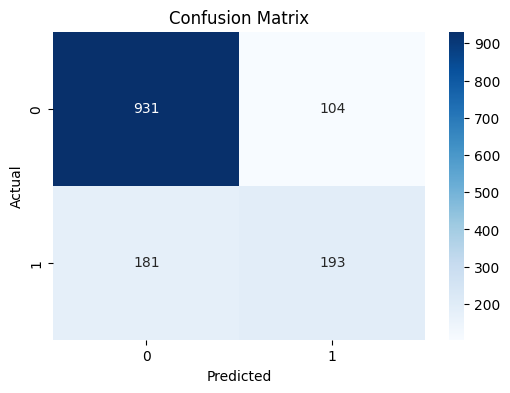

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Success!")

Success!


In [11]:
from sklearn.metrics import roc_auc_score

probabilities = log_model.predict_proba(
    X_test_processed
)[:,1]

y_test_binary = y_test.map({
    "No": 0,
    "Yes": 1
})

auc = roc_auc_score(
    y_test_binary,
    probabilities
)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8423596579606809


In [12]:
import json

metrics = {
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc)
}

with open("../models/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Metrics saved successfully!")

NameError: name 'accuracy' is not defined

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = logistic_model.predict(X_test_processed)

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(
        y_test,
        logistic_model.predict_proba(X_test_processed)[:,1]
    )
}

import json

with open("../models/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print(metrics)

NameError: name 'logistic_model' is not defined

In [14]:
import pandas as pd
import joblib
import json

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Load dataset
df = pd.read_csv("../data/telco_featured.csv")

# Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Load preprocessor
preprocessor = joblib.load("../models/preprocessor.pkl")

# Transform features
X_processed = preprocessor.transform(X)

# Load trained model
model = joblib.load("../models/logistic_regression.pkl")

# Predictions
y_pred = model.predict(X_processed)

# Prediction probabilities
y_prob = model.predict_proba(X_processed)[:, 1]

# Convert target to numeric for ROC-AUC
y_numeric = y.map({
    "No": 0,
    "Yes": 1
})

# Calculate metrics
metrics = {
    "accuracy": float(accuracy_score(y, y_pred)),
    "precision": float(precision_score(y, y_pred, pos_label="Yes")),
    "recall": float(recall_score(y, y_pred, pos_label="Yes")),
    "f1_score": float(f1_score(y, y_pred, pos_label="Yes")),
    "roc_auc": float(roc_auc_score(y_numeric, y_prob))
}

# Save metrics JSON
with open("../models/model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

# Display results
print("Model Metrics:")
print(json.dumps(metrics, indent=4))

print("\nmodel_metrics.json created successfully!")

Model Metrics:
{
    "accuracy": 0.8078943631975011,
    "precision": 0.6724598930481284,
    "recall": 0.5382557517388978,
    "f1_score": 0.5979197622585438,
    "roc_auc": 0.8489870846598304
}

model_metrics.json created successfully!
